# TED Talks — Cleaning & Theme Groups (Week 2)

**Deliverables for April 27:**
1. Parse the tags column
2. Run a full tag frequency analysis
3. Propose final theme groups using tags appearing 50+ times
4. Remove duplicates and null transcripts → produce a clean master dataset

**Inputs:** `../data/ted_merged.csv` (output of week 1's exploration notebook)

**Outputs:**
- `../data/ted_cleaned_with_themes.csv` — the clean master dataset for preprocessing & sentiment work
- `../outputs/theme_group_mapping.csv` — the proposed tag→theme mapping (for the report appendix)
- A few diagnostic plots in `../outputs/`

## 1. Setup

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
sns.set_style('whitegrid')

DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

INPUT_PATH = DATA_DIR / 'ted_merged.csv'
print('Input file exists:', INPUT_PATH.exists())

Input file exists: True


In [2]:
df = pd.read_csv(INPUT_PATH)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
df.head(2)

Loaded 2,467 rows × 21 columns


,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views,transcript,transcript_len_chars,transcript_len_words,num_tags
0,4553,Sir Ken Robinson makes an entertaining and profoundly moving case for creati...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {'id': 1, 'name': 'Beautiful', ...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/images/ted/172559_800x600.jpg', ...",Author/educator,"['children', 'creativity', 'culture', 'dance', 'education', 'parenting', 'te...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_schools_kill_creativity\n,47227110,"Good morning. How are you?(Laughter)It's been great, hasn't it? I've been bl...",17409,3066,7
1,265,"With the same humor and humanity he exuded in ""An Inconvenient Truth,"" Al Go...",977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'id': 3, 'name': 'Courageous', '...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/images/ted/566c14767bd62c5ff760e...",Climate advocate,"['alternative energy', 'cars', 'climate change', 'culture', 'environment', '...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_climate_crisis\n,3200520,"Thank you so much, Chris. And it's truly a great honor to have the opportuni...",11814,2089,9


## 2. Deduplication

Three things to check:
1. **Duplicate URLs** — the join key. Should already be 0 because of the inner merge in week 1, but needs confirming.
2. **Duplicate transcripts** — same text appearing under different URLs (its rare but possible).
3. **Duplicate titles** — same title given on different occasions, not necessarily a problem but worth noting.

In [3]:
n_dup_url        = df['url'].duplicated().sum()
n_dup_transcript = df['transcript'].duplicated().sum()
n_dup_title      = df['title'].duplicated().sum()

print(f'Duplicate URLs:        {n_dup_url}')
print(f'Duplicate transcripts: {n_dup_transcript}')
print(f'Duplicate titles:      {n_dup_title}')

Duplicate URLs:        3
Duplicate transcripts: 3
Duplicate titles:      3


In [4]:
# Inspect any duplicate transcripts to decide what to do
if n_dup_transcript > 0:
    dup_mask = df['transcript'].duplicated(keep=False)
    print(df.loc[dup_mask, ['title', 'main_speaker', 'url']].sort_values('title').head(20))
else:
    print('No duplicate transcripts to inspect.')

                                                           title    main_speaker                                                                              url
1111                                          Listening to shame     Brené Brown                       https://www.ted.com/talks/brene_brown_listening_to_shame\n
1112                                          Listening to shame     Brené Brown                       https://www.ted.com/talks/brene_brown_listening_to_shame\n
1107  Religion, evolution, and the ecstasy of self-transcendence  Jonathan Haidt  https://www.ted.com/talks/jonathan_haidt_humanity_s_stairway_to_self_transce...
1108  Religion, evolution, and the ecstasy of self-transcendence  Jonathan Haidt  https://www.ted.com/talks/jonathan_haidt_humanity_s_stairway_to_self_transce...
1109                                         The $8 billion iPod        Rob Reid                          https://www.ted.com/talks/rob_reid_the_8_billion_ipod\n
1110                        

In [5]:
# Drop any duplicates we found, keeping the first occurrence.
before = len(df)
df = df.drop_duplicates(subset='url', keep='first')
df = df.drop_duplicates(subset='transcript', keep='first')
after = len(df)
print(f'Dropped {before - after} duplicate row(s); {after:,} rows remaining.')

Dropped 3 duplicate row(s); 2,464 rows remaining.


## 3. Null and effectively-empty transcripts

After the inner merge in week 1 there should be no actual nulls in the `transcript` column. We still want to filter out **effectively empty** transcripts: in week 1 we saw the minimum word count was 1, which is clearly a music/performance placeholder rather than a talk we can do sentiment analysis on.

**Decision:** drop transcripts shorter than **100 words** (≈30–45 seconds of speech). This is a defensible cut-off — anything shorter is unlikely to give meaningful sentiment signal — but it's easy to adjust here if the group prefers a different threshold.

In [6]:
# Confirm no actual nulls
n_null = df['transcript'].isna().sum()
print(f'Null transcripts: {n_null}')

# Re-compute lengths in case they changed after dedup (cheap)
df['transcript_len_words'] = df['transcript'].fillna('').str.split().str.len()
df['transcript_len_chars'] = df['transcript'].fillna('').str.len()

Null transcripts: 0


In [7]:
# How many talks fall below typical thresholds?
for threshold in [1, 50, 100, 200, 500]:
    n_below = (df['transcript_len_words'] < threshold).sum()
    print(f'  < {threshold:>4} words: {n_below:>4} talks')

  <    1 words:    0 talks
  <   50 words:   10 talks
  <  100 words:   11 talks
  <  200 words:   22 talks
  <  500 words:  104 talks


In [8]:
# Inspect the very short ones to confirm they're not real talks
df.nsmallest(10, 'transcript_len_words')[['title', 'main_speaker', 'duration', 'transcript_len_words']]

,title,main_speaker,duration,transcript_len_words
146,My magic moves,Kenichi Ebina,212,1
908,"On violin and cello, ""Passacaglia""",Robert Gupta + Joshua Roman,561,1
1173,Dancing with light,Quixotic Fusion,742,1
1796,"A dance in a hurricane of paper, wind and light",Aakash Odedra,590,1
1919,An 11-year-old prodigy performs old-school jazz,Joey Alexander,388,2
1365,"Dance, tiny robots!",Bruno Maisonnier,189,3
2301,An electrifying acoustic guitar performance,Rodrigo y Gabriela,257,4
2000,A musical escape into a world of light and color,Kaki King,691,11
304,Playing invisible turntables,James Burchfield,284,14
574,An all-star set,Herbie Hancock,1505,19


In [9]:
MIN_WORDS = 100
before = len(df)
df = df[df['transcript_len_words'] >= MIN_WORDS].copy()
after = len(df)
print(f'Dropped {before - after} talks shorter than {MIN_WORDS} words; {after:,} rows remaining.')

Dropped 11 talks shorter than 100 words; 2,453 rows remaining.


## 4. Parse the tags column

Tags are stored as a stringified Python list (e.g. `"['business', 'economics']"`). We parse them back to actual lists using `ast.literal_eval`. I think this is safer than the common option.

In [10]:
def parse_tags(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []

df['tags_list'] = df['tags'].apply(parse_tags)
df['num_tags']  = df['tags_list'].apply(len)

print(f'Talks with no tags:    {(df["num_tags"] == 0).sum()}')
print(f'Tags per talk (median): {int(df["num_tags"].median())}')
print(f'Tags per talk (max):    {int(df["num_tags"].max())}')

Talks with no tags:    0
Tags per talk (median): 6
Tags per talk (max):    32


## 5. Full tag frequency analysis

We now flatten all tag applications and count their frequency. The week-1 task flagged the **50+ occurrences threshold** as the cut-off for tags worth using in theme groups. It is frequent enough to give us a usable sample size per theme.

In [11]:
all_tags = [t for tags in df['tags_list'] for t in tags]
tag_counts = pd.Series(all_tags).value_counts()

print(f'Total tag applications: {len(all_tags):,}')
print(f'Unique tags:            {len(tag_counts):,}')
print(f'Tags appearing >= 50:   {(tag_counts >= 50).sum()}')
print(f'Tags appearing >= 100:  {(tag_counts >= 100).sum()}')
print(f'Tags appearing once:    {(tag_counts == 1).sum()}')

Total tag applications: 18,575
Unique tags:            416
Tags appearing >= 50:   102
Tags appearing >= 100:  45
Tags appearing once:    4


In [12]:
# Coverage: what fraction of tag applications come from the 50+ tags
freq_tags = tag_counts[tag_counts >= 50].index
covered = sum(1 for t in all_tags if t in set(freq_tags))
print(f'{covered:,} of {len(all_tags):,} tag applications ({covered/len(all_tags):.1%}) '
      f'come from the {len(freq_tags)} tags that appear >= 50 times.')

13,103 of 18,575 tag applications (70.5%) come from the 102 tags that appear >= 50 times.


In [13]:
# Save the (post-cleaning) tag frequencies — they replace last week's file
tag_counts.to_csv(OUTPUT_DIR / 'tag_frequencies.csv', header=['count'])
print('Saved -> ../outputs/tag_frequencies.csv')

Saved -> ../outputs/tag_frequencies.csv


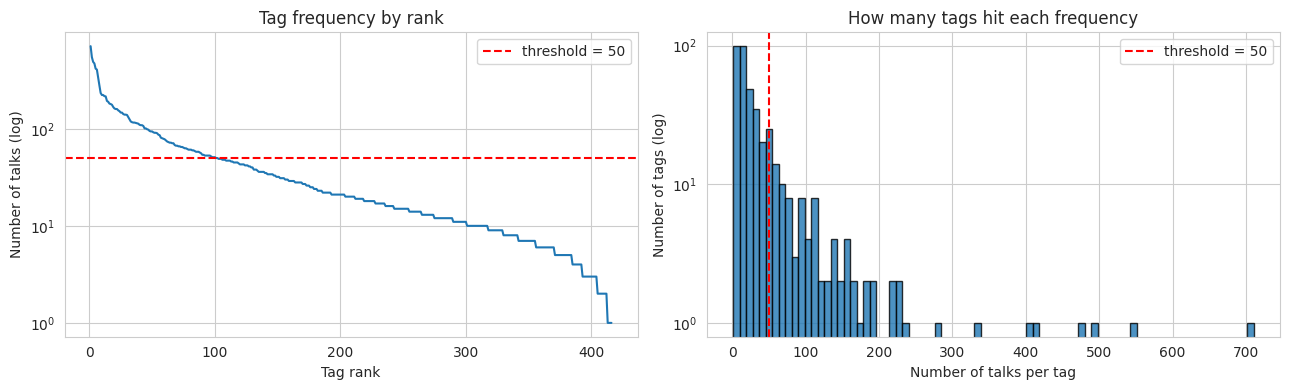

In [14]:
# Visualise the distribution of tag frequencies. The long tail is as expected
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, len(tag_counts) + 1), tag_counts.values)
axes[0].axhline(50, color='red', linestyle='--', label='threshold = 50')
axes[0].set_yscale('log')
axes[0].set_xlabel('Tag rank')
axes[0].set_ylabel('Number of talks (log)')
axes[0].set_title('Tag frequency by rank')
axes[0].legend()

axes[1].hist(tag_counts.values, bins=80, edgecolor='black', alpha=0.8)
axes[1].axvline(50, color='red', linestyle='--', label='threshold = 50')
axes[1].set_yscale('log')
axes[1].set_xlabel('Number of talks per tag')
axes[1].set_ylabel('Number of tags (log)')
axes[1].set_title('How many tags hit each frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tag_frequency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Proposed theme groups

I went through every tag with **≥ 50 occurrences** (102 tags total) and bucketed each into one of the five theme groups, the *unassigned* bucket (general topics like `technology`, `art`, `science`), or *borderline* (could fit several themes; flagged for the group to discuss).

**Rules I used:**
- A tag belongs to a theme if its meaning is squarely inside that theme's domain (e.g. `climate change` is squarely environmental).
- Generic tags that span everything (`technology`, `science`, `TEDx`, `TED Fellows`) are **not** assigned — including them would dilute every theme.
- A talk can belong to multiple theme groups (it's tagged with multiple tags). We treat this as **multi-label**, not exclusive — the team can pick one talk per theme later if needed.

Borderline calls and why I made them:
- `innovation` (224) → **business** (most TED uses are about business innovation; could also be technology)
- `energy` (51) → **environment** (renewable/climate framing dominates; could be technology)
- `social media` (50) → **society** (effects on society, identity, communication)
- `personal growth` (95), `happiness` (72), `identity` (113) → **psychology** (subjective experience / mental life)
- `women` (117), `inequality` (94), `poverty` (54) → **society** (social structure)

In [15]:
# Theme group definitions — only tags from the 50+ list
THEME_GROUPS = {
    'education': [
        'education', 'children', 'parenting',
    ],
    'psychology': [
        'psychology', 'brain', 'neuroscience', 'mind', 'mental health',
        'cognitive science', 'happiness', 'personal growth', 'identity',
    ],
    'society': [
        'society', 'global issues', 'culture', 'social change', 'humanity',
        'community', 'politics', 'women', 'inequality', 'activism',
        'government', 'war', 'religion', 'poverty', 'violence',
        'peace', 'global development', 'social media',
    ],
    'environment': [
        'environment', 'nature', 'animals', 'climate change', 'sustainability',
        'oceans', 'green', 'biodiversity', 'ecology', 'energy',
    ],
    'business': [
        'business', 'economics', 'entrepreneur', 'work', 'innovation',
    ],
}

# Sanity check: every tag in the mapping must actually exist in the dataset and meet the 50+ threshold
for theme, tags in THEME_GROUPS.items():
    for tag in tags:
        count = tag_counts.get(tag, 0)
        if count < 50:
            print(f'  ⚠  {theme!r}: tag {tag!r} only appears {count} times')
        else:
            pass  # silent OK
print('Theme group definitions validated against the 50+ threshold.')

Theme group definitions validated against the 50+ threshold.


In [16]:
# Persist the mapping as a tidy CSV for the report appendix
mapping_rows = [
    {'theme': theme, 'tag': tag, 'tag_count_in_corpus': int(tag_counts.get(tag, 0))}
    for theme, tags in THEME_GROUPS.items()
    for tag in tags
]
mapping_df = pd.DataFrame(mapping_rows).sort_values(['theme', 'tag_count_in_corpus'], ascending=[True, False])
mapping_df.to_csv(OUTPUT_DIR / 'theme_group_mapping.csv', index=False)
mapping_df

,theme,tag,tag_count_in_corpus
40,business,business,337
44,business,innovation,223
41,business,economics,160
43,business,work,71
42,business,entrepreneur,63
0,education,education,147
1,education,children,140
2,education,parenting,50
30,environment,environment,162
31,environment,nature,114


## 7. Apply theme groups to the dataset

For each talk we add:
- One **binary column per theme** (`theme_education`, `theme_psychology`, …) — `True` if any of the talk's tags belongs to that theme
- `num_themes` — how many of the five themes the talk falls into
- `themes_str` — comma-joined list of themes (handy for groupbys later)

In [17]:
# Reverse lookup: tag -> theme
TAG_TO_THEME = {tag: theme for theme, tags in THEME_GROUPS.items() for tag in tags}

def themes_for(tags_list):
    return sorted({TAG_TO_THEME[t] for t in tags_list if t in TAG_TO_THEME})

df['themes'] = df['tags_list'].apply(themes_for)
df['themes_str'] = df['themes'].apply(lambda lst: ','.join(lst))
df['num_themes'] = df['themes'].apply(len)

for theme in THEME_GROUPS:
    df[f'theme_{theme}'] = df['themes'].apply(lambda lst: theme in lst)

df[['title', 'tags_list', 'themes', 'num_themes']].head(5)

,title,tags_list,themes,num_themes
0,Do schools kill creativity?,"[children, creativity, culture, dance, education, parenting, teaching]","[education, society]",2
1,Averting the climate crisis,"[alternative energy, cars, climate change, culture, environment, global issu...","[environment, society]",2
2,Simplicity sells,"[computers, entertainment, interface design, media, music, performance, simp...",[],0
3,Greening the ghetto,"[MacArthur grant, activism, business, cities, environment, green, inequality...","[business, environment, society]",3
4,The best stats you've ever seen,"[Africa, Asia, Google, demo, economics, global development, global issues, h...","[business, society]",2


## 8. Validation — does this give us a usable dataset?

Three checks:
1. **Talks per theme** — is each group big enough for sentiment analysis?
2. **Overlap between themes** — how often do talks fall into two themes at once?
3. **Talks not in any theme** — what % of the corpus do we lose?

In [18]:
# (1) Talks per theme
theme_counts = pd.Series({theme: int(df[f'theme_{theme}'].sum()) for theme in THEME_GROUPS})
theme_counts = theme_counts.sort_values(ascending=False)
print('Talks per theme:')
print(theme_counts)

Talks per theme:
society        1318
business        630
psychology      462
environment     425
education       251
dtype: int64


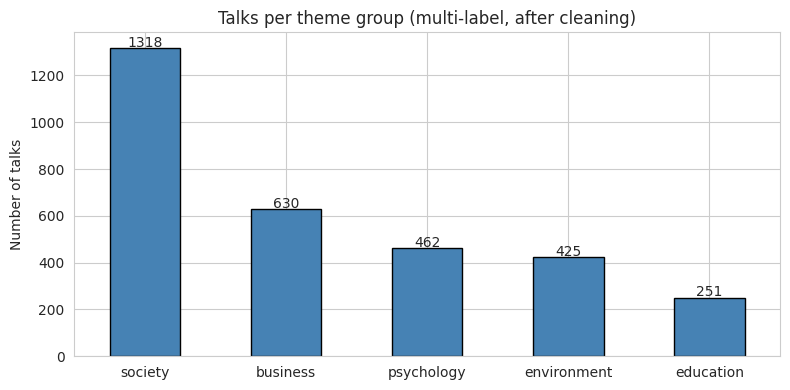

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
theme_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_ylabel('Number of talks')
ax.set_title('Talks per theme group (multi-label, after cleaning)')
for i, v in enumerate(theme_counts.values):
    ax.text(i, v + 5, str(v), ha='center')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'talks_per_theme.png', dpi=150, bbox_inches='tight')
plt.show()

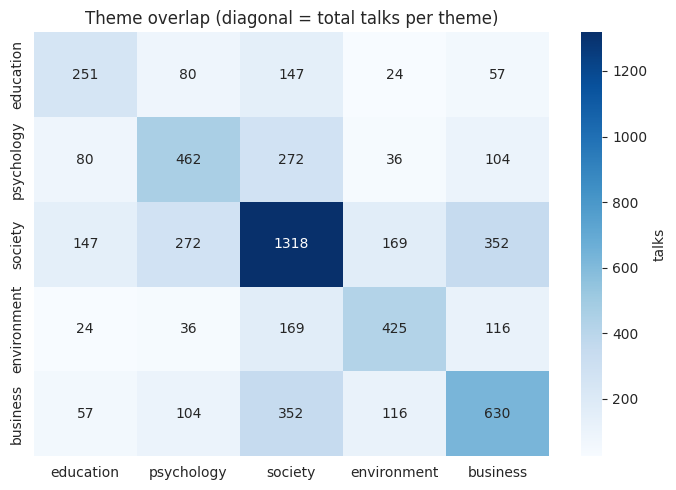

In [20]:
# (2) Overlap matrix — co-occurrence of theme pairs
themes = list(THEME_GROUPS.keys())
overlap = np.zeros((len(themes), len(themes)), dtype=int)
for i, a in enumerate(themes):
    for j, b in enumerate(themes):
        overlap[i, j] = ((df[f'theme_{a}']) & (df[f'theme_{b}'])).sum()
overlap_df = pd.DataFrame(overlap, index=themes, columns=themes)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(overlap_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'talks'}, ax=ax)
ax.set_title('Theme overlap (diagonal = total talks per theme)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'theme_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# (3) Distribution of how many themes each talk spans
print(df['num_themes'].value_counts().sort_index())
print()
print(f"Talks in ≥ 1 theme:  {(df['num_themes'] >= 1).sum():>5,} ({(df['num_themes'] >= 1).mean():.1%})")
print(f"Talks in 0 themes:   {(df['num_themes'] == 0).sum():>5,} ({(df['num_themes'] == 0).mean():.1%})")
print(f"Talks in 2+ themes:  {(df['num_themes'] >= 2).sum():>5,} ({(df['num_themes'] >= 2).mean():.1%})")

num_themes
0     481
1    1081
2     686
3     189
4      14
5       2
Name: count, dtype: int64

Talks in ≥ 1 theme:  1,972 (80.4%)
Talks in 0 themes:     481 (19.6%)
Talks in 2+ themes:    891 (36.3%)


In [22]:
# What do the unclassified talks look like? Inspect their top tags to see what we're missing
unclassified = df[df['num_themes'] == 0]
uncl_tags = pd.Series([t for tl in unclassified['tags_list'] for t in tl]).value_counts()
print(f'{len(unclassified):,} unclassified talks; their top 15 tags are:')
print(uncl_tags.head(15))

481 unclassified talks; their top 15 tags are:
technology       196
design           132
entertainment    100
science          100
art               79
TEDx              67
music             66
creativity        62
performance       44
TED Fellows       41
health            39
live music        38
humor             37
medicine          36
biology           34
Name: count, dtype: int64


**Interpretation note:** The unclassified talks are dominated by `technology`, `science`, `art`, `design`, `entertainment`, `music`, `health`, `medicine` — exactly the kind of broad/general tags I deliberately *didn't* assign to any theme, because doing so would dilute the themes' semantic coherence. This is a design choice: we trade coverage for cleaner theme definitions.

If you guys prefer higher coverage we could add e.g. `health` and `medicine` to a new *health* theme, or fold `technology` into *business*. Easy to revisit.

## 9. Save the clean master dataset

This is the file Person 2 (preprocessing) and Person 3 (sentiment) will start from on May 4.

In [23]:
# Drop the helper list-typed columns before saving (they don't round-trip cleanly through CSV)
to_drop = ['tags_list', 'themes']
out_df = df.drop(columns=[c for c in to_drop if c in df.columns])

out_path = DATA_DIR / 'ted_cleaned_with_themes.csv'
out_df.to_csv(out_path, index=False)
print(f'Saved -> {out_path}   ({len(out_df):,} rows × {out_df.shape[1]} columns)')
print('\nNew columns added in this notebook:')
print(['themes_str', 'num_themes'] + [f'theme_{t}' for t in THEME_GROUPS])

Saved -> ../data/ted_cleaned_with_themes.csv   (2,453 rows × 28 columns)

New columns added in this notebook:
['themes_str', 'num_themes', 'theme_education', 'theme_psychology', 'theme_society', 'theme_environment', 'theme_business']


## 10. Summary

In [24]:
summary = f"""
# Week 2 Summary — Cleaning & Theme Groups

## Cleaning
- Started from {pd.read_csv(INPUT_PATH).shape[0]:,} merged rows (week 1 output)
- Dropped duplicates (URL + transcript text)
- Dropped transcripts shorter than {MIN_WORDS} words (music/performance placeholders)
- **Final clean dataset: {len(df):,} rows**

## Tag analysis
- {len(tag_counts):,} unique tags total, {(tag_counts >= 50).sum()} of them appear in 50+ talks
- The 50+ tags account for {covered/len(all_tags):.0%} of all tag applications

## Theme groups (multi-label, only using 50+ tags)
{theme_counts.to_string()}

- Talks classified into ≥ 1 theme: {(df['num_themes'] >= 1).sum():,} ({(df['num_themes'] >= 1).mean():.0%})
- Talks in 2+ themes (overlap):     {(df['num_themes'] >= 2).sum():,} ({(df['num_themes'] >= 2).mean():.0%})
- Talks in 0 themes (unclassified): {(df['num_themes'] == 0).sum():,} ({(df['num_themes'] == 0).mean():.0%})

## Outputs produced
- ../data/ted_cleaned_with_themes.csv  — master dataset for week 3
- ../outputs/theme_group_mapping.csv    — tag→theme mapping (report appendix)
- ../outputs/tag_frequencies.csv        — refreshed post-cleaning
- ../outputs/talks_per_theme.png        — talks per theme bar chart
- ../outputs/theme_overlap.png          — theme co-occurrence heatmap
- ../outputs/tag_frequency_distribution.png  — long-tail diagnostic

## Decisions for the you to confirm
1. Minimum transcript length set to {MIN_WORDS} words — adjust here if too aggressive/lenient
2. Theme membership is **multi-label** (a talk can be in several themes). If the analysis later requires non-overlapping groups, we'd need a tie-break rule.
3. Borderline tags I assigned: `innovation`→business, `energy`→environment, `social media`→society. Easy to move.
4. Generic tags (`technology`, `science`, `TEDx`, etc.) are deliberately unassigned to keep themes semantically tight — this is why ~{(df['num_themes'] == 0).mean():.0%} of talks aren't in any theme.
"""
print(summary)

with open(OUTPUT_DIR / 'week2_summary.md', 'w') as f:
    f.write(summary)
print('Summary saved to ../outputs/week2_summary.md')


# Week 2 Summary — Cleaning & Theme Groups

## Cleaning
- Started from 2,467 merged rows (week 1 output)
- Dropped duplicates (URL + transcript text)
- Dropped transcripts shorter than 100 words (music/performance placeholders)
- **Final clean dataset: 2,453 rows**

## Tag analysis
- 416 unique tags total, 102 of them appear in 50+ talks
- The 50+ tags account for 71% of all tag applications

## Theme groups (multi-label, only using 50+ tags)
society        1318
business        630
psychology      462
environment     425
education       251

- Talks classified into ≥ 1 theme: 1,972 (80%)
- Talks in 2+ themes (overlap):     891 (36%)
- Talks in 0 themes (unclassified): 481 (20%)

## Outputs produced
- ../data/ted_cleaned_with_themes.csv  — master dataset for week 3
- ../outputs/theme_group_mapping.csv    — tag→theme mapping (report appendix)
- ../outputs/tag_frequencies.csv        — refreshed post-cleaning
- ../outputs/talks_per_theme.png        — talks per theme bar chart
- ../outputs